In [1]:
from loopr.config.training_nn import TrainingNNConfig

Visualize Data

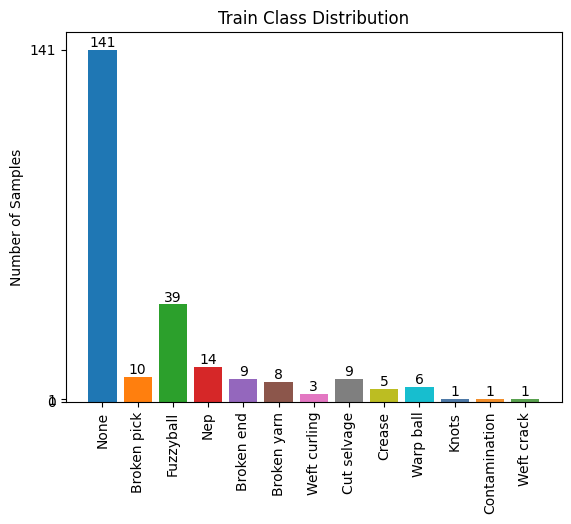

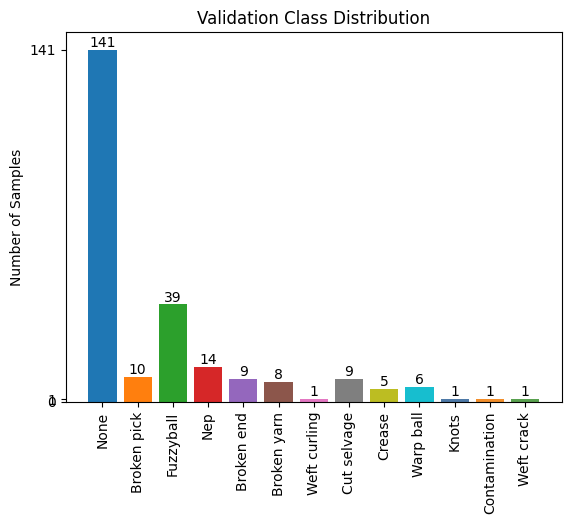

In [31]:
from loopr.data.classification import (
    ClassificationDataset)
from loopr.data.contrastive import get_train_transforms, get_valid_transforms
from torch.utils.data import DataLoader
from loopr.eda.class_visualization import number_of_files_per_class

total_val_ds =  ClassificationDataset(
    transforms=get_train_transforms(), 
    training=False,
    train_split=0,
    censor_files=False,
    limited_classes=[]
)
total_val_loader   = DataLoader(total_val_ds,   batch_size=30, shuffle=True,
                          num_workers=TrainingNNConfig.num_workers, pin_memory=True)
censored_val_ds =  ClassificationDataset(
    transforms=get_valid_transforms(), 
    training=False,
    train_split=0,
    censor_files=False,
    limited_classes=[16]
)
censored_val_loader   = DataLoader(censored_val_ds,   batch_size=30, shuffle=False,
                          num_workers=TrainingNNConfig.num_workers, pin_memory=True)
number_of_files_per_class(total_val_ds, censored_val_ds)

epoch: 0
Train Loss (Contrastive): 4.137736323173158e-05


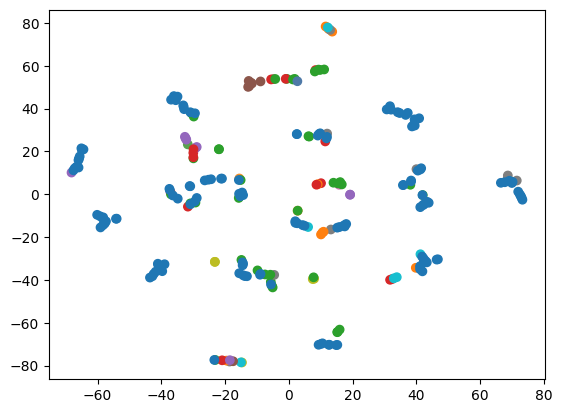

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
Class Accuracies:
13
	0:0.0
	1:0.0
	2:0.0
	3:0.0
	4:0.0
	5:0.0
	6:1.0
	7:0.0
	8:0.0
	9:0.0
	10:1.0
	11:1.0
	12:1.0
epoch: 1
Train Loss (Contrastive): 598.38134765625
epoch: 2
Train Loss (Contrastive): 2577.716796875
epoch: 3
Train Loss (Contrastive): 1067.110107421875
epoch: 4
Train Loss (Contrastive): 156.17153930664062
epoch: 5
Train Loss (Contrastive): 290.2156677246094
epoch: 6
Train Loss (Contrastive): 168.0502471923828
epoch: 7
Train Loss (Contrastive): 33.75286865234375
epoch: 8
Train Loss (Contrastive): 28.337221145629883
epoch: 9
Train Loss (Contrastive): 10.952725410461426
epoch: 10
Train Loss (Contrastive): 5.612177848815918


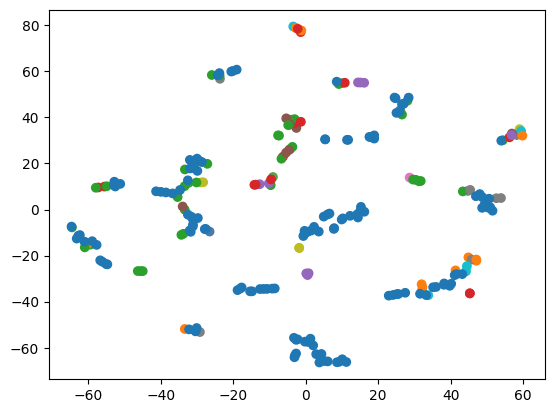

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
Class Accuracies:
13
	0:0.0
	1:0.0
	2:0.0
	3:0.0
	4:0.0
	5:0.0
	6:1.0
	7:0.0
	8:0.0
	9:0.0
	10:1.0
	11:1.0
	12:1.0
epoch: 11
Train Loss (Contrastive): 5.122778415679932
epoch: 12


Traceback (most recent call last):
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py", line 270, in _feed
    send_bytes(obj)
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 427, in _send_bytes
    self._send(header + buf)
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 384, in _send
    n = write(self._handle, buf)
        ^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 9] Bad file descriptor
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py", li

Train Loss (Contrastive): 3.554877758026123
epoch: 13
Train Loss (Contrastive): 3.4636659622192383
epoch: 14
Train Loss (Contrastive): 3.8287298679351807
epoch: 15
Train Loss (Contrastive): 4.42292594909668
epoch: 16
Train Loss (Contrastive): 7.215461730957031
epoch: 17
Train Loss (Contrastive): 13.576105117797852
epoch: 18
Train Loss (Contrastive): 33.073997497558594
epoch: 19
Train Loss (Contrastive): 81.86800384521484
epoch: 20
Train Loss (Contrastive): 195.65296936035156


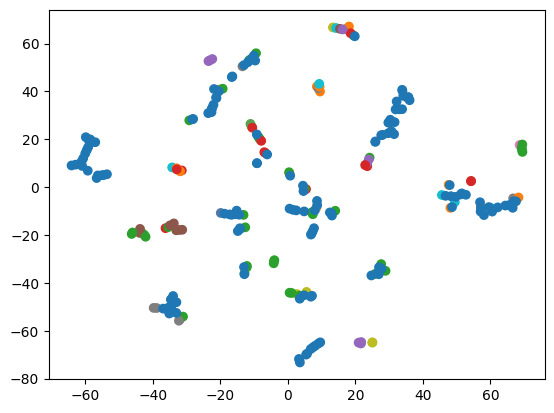

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
Class Accuracies:
13
	0:0.0
	1:0.0
	2:0.0
	3:0.0
	4:0.0
	5:0.0
	6:1.0
	7:0.0
	8:0.0
	9:0.0
	10:1.0
	11:1.0
	12:1.0
epoch: 21
Train Loss (Contrastive): 401.0154113769531
epoch: 22
Train Loss (Contrastive): 644.5318603515625
epoch: 23
Train Loss (Contrastive): 875.8441772460938
epoch: 24
Train Loss (Contrastive): 1069.717041015625
epoch: 25
Train Loss (Contrastive): 1194.5909423828125
epoch: 26
Train Loss (Contrastive): 1123.70849609375
epoch: 27
Train Loss (Contrastive): 839.8173828125
epoch: 28
Train Loss (Contrastive): 538.4674072265625
epoch: 29
Train Loss (Contrastive): 312.8118896484375
epoch: 30


KeyboardInterrupt: 

In [32]:
from torch import nn
import torch
from collections import defaultdict
from sklearn.manifold import TSNE
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import math
import matplotlib.pyplot as plt

from loopr.models.unet import load_unet
from loopr.models.mlp import create_mlp
from loopr.losses.contrastive import ContrastiveLoss
from loopr.eda.class_visualization import colors
from loopr.data.utils import tile_image

def display_contrastive_space(
    censored_data: DataLoader,
    unet_model: nn.Module,
    linear_layer: nn.Module
):
    unet_model.eval()
    linear_layer.eval()
    centroid_counts = defaultdict(int)
    centroids = dict()
    color_choices = []
    all_points = []
    # Calculate centroids of each class
    for images, dense_classes, metas in censored_data:
            total_embeddings = torch.zeros(len(images), 7*128).cuda()
            for i, (image, individual_class) in enumerate(zip(images, dense_classes)):
                image_tiles = tile_image(image)
        
                embeddings = unet_model.encode(image_tiles.cuda())
                
                embeddings = embeddings.reshape(len(image_tiles),-1)
                domain_embedded = linear_layer(embeddings).reshape(-1).detach().cpu()
                total_embeddings[i,:] = domain_embedded
            
                color_choices.append(colors[individual_class])
                if individual_class not in centroids:
                    centroids[individual_class.item()] = domain_embedded
                else:
                    centroids[individual_class] += domain_embedded
                all_points.append(domain_embedded)
                centroid_counts[individual_class.item()] += 1

            
    # Normalize centroids
    for individual_class in centroids:
        centroids[individual_class] /= centroid_counts[individual_class]

    # See how many are in their correct class
    class_correct = defaultdict(int)
    class_count = defaultdict(int)
    current_classes = set()
    all_points = torch.stack(all_points)
    for images, dense_classes, metas in censored_data:
        total_embeddings = torch.zeros(len(images), 7*128).cuda()
        for i, (image, individual_class) in enumerate(zip(images, dense_classes)):
            image_tiles = tile_image(image)
            embeddings = unet_model.encode(image_tiles.cuda())
            
            embeddings = embeddings.reshape(len(image_tiles),-1)
            domain_embedded = linear_layer(embeddings).reshape(-1).detach().cpu()
            total_embeddings[i,:] = domain_embedded
            class_count[individual_class.item()] += 1
            current_classes.add(individual_class.item())
        
        for individual_class, embedding in zip(dense_classes, total_embeddings):
            min_dist = math.inf
            prediction = None
            for centroid_class, centroid_embedding in centroids.items():
                if (embedding.cpu()-centroid_embedding).norm() < min_dist:
                    prediction = centroid_class
                    min_dist = (embedding.cpu()-centroid_embedding).norm()

            if prediction == individual_class:
                class_correct[individual_class.item()] += 1
            # else:
            #     print(prediction, individual_class)
    X_embedded = TSNE(n_components=2, learning_rate='auto',
              init='random', perplexity=3).fit_transform(all_points)
    plt.scatter(X_embedded[:,0],X_embedded[:,1], color=color_choices)
    plt.show()

    unet_model.train()
    linear_layer.train()
    print(current_classes)
    return dict({
        individual_class: class_correct[individual_class]/class_count[individual_class]
        for individual_class in current_classes
    })

def train_contrastive(censored_val_loader: DataLoader):
    # Load Models
    unet_model = load_unet(TrainingNNConfig.pretrained_path,gpu=True)
    mlp = create_mlp(TrainingNNConfig.pretrained_mlp_path, gpu=True)
    linear_layer = list(mlp.children())[0]

    # Loss / Opt.
    pos_weight = torch.ones([4]).cuda()  # All weights are equal to 1
    pos_weight[0] = 95/141
    pos_weight[1] = 7/141
    pos_weight[2] = 30/141
    pos_weight[3] = 9/141
    criterion = ContrastiveLoss()
    optimizer = Adam(
        mlp.parameters(), 
        lr=TrainingNNConfig.lr, 
        weight_decay=TrainingNNConfig.weight_decay
    )
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode="max", 
        factor=0.5, 
        patience=3
    )
    
    training_losses = []
    best_score = 0
    
    for epoch in range(TrainingNNConfig.epochs):
        # Run through training:
        print(f"epoch: {epoch}")
        train_loss_total = 0
        train_num_batches = 0
        for images, dense_classes, metas in censored_val_loader:
            if len(images) % 2 != 0:
                continue
            optimizer.zero_grad()
            total_embeddings = torch.zeros(len(images), 7*128).cuda()
            for i, (image, individual_class) in enumerate(zip(images, dense_classes)):
                image_tiles = tile_image(image)

                embeddings = unet_model.encode(image_tiles.cuda())
                embeddings = embeddings.reshape(len(image_tiles),-1)
                domain_embedded = linear_layer(embeddings).reshape(-1)
                total_embeddings[i,:] = domain_embedded
            x_1 = total_embeddings[0::2]
            x_2 = total_embeddings[1::2]
            label = (dense_classes[0::2] != dense_classes[1::2]).float().cuda()
            loss = criterion(x_1,x_2,label)
            training_losses.append(loss.sum().item())
            train_num_batches += 1
            
            loss.backward()
            optimizer.step()
        # validate
        # mlp.eval()
        val_score = 0
        val_loss = 0
        # num_val_batches = 0
    
    
        # val_losses.append(val_loss/ num_val_batches)
        # val_scores.append(val_score / num_val_batches)
        print(f"Train Loss (Contrastive): {training_losses[-1]}")
        if epoch % 10 == 0:
            class_accuracies = display_contrastive_space(censored_val_loader, unet_model, linear_layer)
            print(f"Class Accuracies:")
            print(len(class_accuracies))
            for class_label, class_accuracy in class_accuracies.items():
                print(f"\t{class_label}:{class_accuracy}")
            
        if training_losses[-1] > best_score:
            best_score = train_loss_total / train_num_batches
            torch.save(linear_layer, TrainingNNConfig.pretrained_contrastive_path)
train_contrastive(censored_val_loader)

In [ ]:
model_dict = torch.load(pretrained_model_path, weights_only=False)
unet_model = UNetResNet18().cuda()
unet_model.load_state_dict(model_dict)
unet_model = unet_model.eval()
print()
mlp = torch.load(pretrained_mlp_path, weights_only=False)
mlp = mlp.eval()
linear_layer = list(mlp.children())[0]

import torch.nn as nn
 



criterion = ContrastiveLoss()
optimizer = Adam(linear_layer.parameters(), lr=0.0001, weight_decay=0.003)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

In [ ]:


training_losses = []
best_score = 0
model_file = "best_contrastive_layer.pth"
for epoch in range(100):
    # Run through training:
    print(f"epoch: {epoch}")
    train_loss_total = 0
    train_num_batches = 0
    for images, dense_classes, metas in censored_val_loader:
        if len(images) % 2 != 0:
            continue
            
        embeddings = unet_model.encode(images.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        domain_embedded = linear_layer(embeddings.cuda())
        optimizer.zero_grad()
        x_1 = domain_embedded[0::2]
        x_2 = domain_embedded[1::2]
        label = (dense_classes[0::2] != dense_classes[1::2]).float().cuda()
        loss = criterion(x_1,x_2,label)
        training_losses.append(loss.sum().item())
        train_num_batches += 1
        loss.backward()
        optimizer.step()
    val_score = 0
    val_loss = 0
    print(f"Train Loss (BCE + lambda * L2): {training_losses[-1]}")
    # print(f"Validation Score (F1 micro score): {val_score / num_val_batches}")
    # mlp.train()
    if training_losses[-1] > best_score:
        best_score = train_loss_total / train_num_batches
        torch.save(linear_layer, model_file)

In [ ]:
import math
pretrained_contrastive_path = "best_contrastive_layer.pth"
model_dict = torch.load(pretrained_model_path, weights_only=False)
unet_model = UNetResNet18().cuda()
unet_model.load_state_dict(model_dict)
unet_model = unet_model.eval()

mlp = torchvision.ops.MLP(
    in_channels=204800, 
    hidden_channels=[256, 4], 
    activation_layer=torch.nn.modules.activation.ReLU, 
    bias= True, dropout= 0.001).cuda()

linear_layer = list(mlp.children())[0]
linear_layer = torch.load(pretrained_contrastive_path, weights_only=False)


del mlp
print()
from sklearn.manifold import TSNE
# make forward
class FewShotFaultDetector(nn.Module):
    def __init__(self, censored_data: DataLoader, distance_metric = "l2_norm"):
        super().__init__()
        self.distance_metric = distance_metric

        model_dict = torch.load(pretrained_model_path, weights_only=False)
        self.centroids = dict()
        all_points = []
        colors = []
        color_choices = [
        "#4E79A7",  # blue
        "#F28E2B",  # orange
        "#E15759",  # red
        "#76B7B2",  # teal
        "#59A14F",  # green
        "#EDC948",  # yellow
        "#B07AA1",  # purple
        "#FF9DA7",  # pink
        "#9C755F",  # brown
        "#BAB0AC",  # gray
        "#86BCB6",  # light teal
        "#D37295",   # magenta
        "#000000"   # magenta
        ]
        centroid_counts = defaultdict(int)
        # Calculate centroids of each class
        for images, dense_classes, metas in censored_data:
            embeddings = unet_model.encode(images.cuda())
            embeddings = embeddings.reshape(len(embeddings), -1)
            domain_embedded = linear_layer(embeddings).cpu().detach()
            for individual_class, embedding in zip(dense_classes, domain_embedded):
                if individual_class == 6:
                    colors.append(color_choices[individual_class]) 
                else:
                    colors.append("black") 
                if individual_class not in self.centroids:
                    self.centroids[individual_class] = embedding
                else:
                    self.centroids[individual_class] += embedding
                all_points.append(embedding)
                centroid_counts[individual_class] += 1
        all_points = torch.stack(all_points)
        X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(all_points)
        plt.scatter(X_embedded[:,0],X_embedded[:,1], color=colors)
        plt.show()
        
        
        # Normalize centroids
        for individual_class in self.centroids:
            self.centroids[individual_class] /= centroid_counts[individual_class]


    def forward(self, x):
            
        embeddings = unet_model.encode(x.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        domain_embedded = linear_layer(embeddings).cpu().detach()
        predicted_classes = []
        for embedding in domain_embedded:
            curr_dist = math.inf if self.distance_metric == "l2_norm" else -1
            predicted_class = -1
            
            for class_ind, centroid in self.centroids.items():
                    
                if self.distance_metric == "l2_norm":
                    if (centroid - embedding).norm() < curr_dist:
                        curr_dist = (centroid - embedding).norm()
                        predicted_class = class_ind
                else:
                    cosi = torch.nn.CosineSimilarity(dim=0)
                    cos_output = cosi(centroid, embedding)
                    if cos_output > curr_dist:
                        curr_dist = cos_output
                        predicted_class = class_ind
            predicted_classes.append(predicted_class)  
        return predicted_classes

    def evaluate(self, class_ind: int, uncensored_data: DataLoader):
        total = 0
        correct = 0
        for images, dense_classes, metas in uncensored_data:
            predicted_classes = self.forward(images)
            for actual, predicted in zip(dense_classes, predicted_classes):
                if actual == class_ind:
                    total += 1
                    # Record this
                    if predicted == actual:
                        correct += 1
        return correct / total
few_shot_detector = FewShotFaultDetector(censored_val_loader)

In [ ]:
few_shot_detector.evaluate(0,uncensored_data=total_val_ds)